<a href="https://colab.research.google.com/github/nidhikulal11/Fish-Anomaly-Detection/blob/main/03_Phase3_Roboflow_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os
import cv2
import json
import shutil
import logging
import numpy as np
import pandas as pd

from pathlib import Path
from dataclasses import dataclass
from datetime import datetime

from typing import Dict
from typing import List
from typing import Tuple

from tqdm import tqdm

from skimage.metrics import structural_similarity as ssim

In [3]:
@dataclass
class ProjectConfig:

    project_root: Path = Path("/content/drive/MyDrive/FishProject")

    input_dir: Path = Path("/content/drive/MyDrive/FishProject/clahe_frames")

    roboflow_dir: Path = Path("/content/drive/MyDrive/FishProject/roboflow_dataset")

    metadata_dir: Path = Path("/content/drive/MyDrive/FishProject/metadata")

    reports_dir: Path = Path("/content/drive/MyDrive/FishProject/reports")

    logs_dir: Path = Path("/content/drive/MyDrive/FishProject/logs")

    similarity_threshold: float = 0.85

    image_extensions = (
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".tif",
        ".tiff"
    )

config = ProjectConfig()

In [4]:
(config.roboflow_dir / "images").mkdir(parents=True, exist_ok=True)
(config.roboflow_dir / "labels").mkdir(parents=True, exist_ok=True)

config.metadata_dir.mkdir(exist_ok=True)
config.reports_dir.mkdir(exist_ok=True)
config.logs_dir.mkdir(exist_ok=True)

In [5]:
for path in config.input_dir.iterdir():
    print(path)

/content/drive/MyDrive/FishProject/clahe_frames/healthy
/content/drive/MyDrive/FishProject/clahe_frames/unhealthy


In [6]:
from pathlib import Path

for category in config.input_dir.iterdir():
    if category.is_dir():
        print(f"\n{category.name}")
        for item in category.iterdir():
            print("   ", item.name)


healthy
    IMG_5440
    IMG_5441
    Screen Recording 2026-06-22 145225

unhealthy
    IMG_3374unhealthy


In [10]:
import logging

logger = logging.getLogger("Phase3")

logger.handlers.clear()

logger.setLevel(logging.INFO)

logger.propagate = False   # Prevent duplicate logs

formatter = logging.Formatter(
    "%(asctime)s | %(levelname)s | %(message)s"
)

file_handler = logging.FileHandler(
    config.logs_dir / "phase3.log"
)

file_handler.setFormatter(formatter)

stream_handler = logging.StreamHandler()

stream_handler.setFormatter(formatter)

logger.addHandler(file_handler)
logger.addHandler(stream_handler)

logger.info("=" * 70)
logger.info("Phase 3 Roboflow Dataset Preparation Started")
logger.info("=" * 70)

2026-06-30 04:39:53,756 | INFO | ======================================================================
2026-06-30 04:39:53,763 | INFO | Phase 3 Roboflow Dataset Preparation Started
2026-06-30 04:39:53,764 | INFO | ======================================================================


In [11]:
class ProjectDirectoryValidator:
    """
    Validates the required project directory structure.
    """

    def __init__(self, config):
        self.config = config

    def validate(self):

        required = [
            self.config.input_dir,
            self.config.roboflow_dir,
            self.config.metadata_dir,
            self.config.reports_dir,
            self.config.logs_dir
        ]

        success = True

        logger.info("=" * 60)
        logger.info("Validating project directories")
        logger.info("=" * 60)

        for folder in required:

            if folder.exists():

                logger.info(f"[OK] {folder}")

            else:

                logger.error(f"[MISSING] {folder}")

                success = False

        return success

In [12]:
validator = ProjectDirectoryValidator(config)

validator.validate()

2026-06-30 04:40:13,175 | INFO | ============================================================
2026-06-30 04:40:13,176 | INFO | Validating project directories
2026-06-30 04:40:13,177 | INFO | ============================================================
2026-06-30 04:40:13,179 | INFO | [OK] /content/drive/MyDrive/FishProject/clahe_frames
2026-06-30 04:40:13,181 | INFO | [OK] /content/drive/MyDrive/FishProject/roboflow_dataset
2026-06-30 04:40:13,183 | INFO | [OK] /content/drive/MyDrive/FishProject/metadata
2026-06-30 04:40:13,184 | INFO | [OK] /content/drive/MyDrive/FishProject/reports
2026-06-30 04:40:13,186 | INFO | [OK] /content/drive/MyDrive/FishProject/logs


True

step 10

In [13]:
class DatasetScanner:
    """
    Production-grade dataset scanner.

    Builds a structured catalog that will be reused by
    later research phases.
    """

    def __init__(self, config):
        self.config = config

    def _extract_frame_number(self, image_path: Path, default: int) -> int:
        """
        Extract frame number from filename.

        Example:
            frame_000123.jpg -> 123

        Falls back to sequential index if parsing fails.
        """
        stem = image_path.stem

        digits = "".join(c for c in stem if c.isdigit())

        if digits:
            return int(digits)

        return default

    def scan(self):

        catalog = {}

        total_images = 0

        logger.info("=" * 70)
        logger.info("Scanning Dataset")
        logger.info("=" * 70)

        for category_dir in sorted(self.config.input_dir.iterdir()):

            if not category_dir.is_dir():
                continue

            category = category_dir.name

            catalog[category] = {}

            logger.info(f"Category : {category}")

            for video_dir in sorted(category_dir.iterdir()):

                if not video_dir.is_dir():
                    continue

                video_name = video_dir.name

                image_files = sorted(
                    [
                        img
                        for img in video_dir.iterdir()
                        if img.suffix.lower() in self.config.image_extensions
                    ]
                )

                frames = []

                for idx, image_path in enumerate(image_files):

                    frame_info = {

                        "frame_number": self._extract_frame_number(
                            image_path,
                            idx
                        ),

                        "filename": image_path.name,

                        "path": image_path,

                        "selected": False,

                        "ssim_score": None
                    }

                    frames.append(frame_info)

                catalog[category][video_name] = frames

                logger.info(
                    f"{video_name:<45} {len(frames):>5} frames"
                )

                total_images += len(frames)

        logger.info("-" * 70)
        logger.info(f"Total Images : {total_images}")

        return catalog

In [14]:
scanner = DatasetScanner(config)

catalog = scanner.scan()

2026-06-30 04:43:57,957 | INFO | ======================================================================
2026-06-30 04:43:57,960 | INFO | Scanning Dataset
2026-06-30 04:43:57,961 | INFO | ======================================================================
2026-06-30 04:43:57,964 | INFO | Category : healthy
2026-06-30 04:43:57,973 | INFO | IMG_5440                                        109 frames
2026-06-30 04:43:57,981 | INFO | IMG_5441                                        157 frames
2026-06-30 04:43:57,988 | INFO | Screen Recording 2026-06-22 145225              110 frames
2026-06-30 04:43:57,990 | INFO | Category : unhealthy
2026-06-30 04:43:58,004 | INFO | IMG_3374unhealthy                               247 frames
2026-06-30 04:43:58,006 | INFO | ----------------------------------------------------------------------
2026-06-30 04:43:58,007 | INFO | Total Images : 623


In [15]:
total = 0

for category, videos in catalog.items():

    print("\n", "=" * 60)
    print(category.upper())
    print("=" * 60)

    for video, frames in videos.items():

        print(f"{video}")

        print(f"Frames : {len(frames)}")

        total += len(frames)

print("\nTotal Images :", total)


HEALTHY
IMG_5440
Frames : 109
IMG_5441
Frames : 157
Screen Recording 2026-06-22 145225
Frames : 110

UNHEALTHY
IMG_3374unhealthy
Frames : 247

Total Images : 623


In [16]:
first = catalog["healthy"]["IMG_5440"][0]

first

{'frame_number': 0,
 'filename': 'frame_000000.jpg',
 'path': PosixPath('/content/drive/MyDrive/FishProject/clahe_frames/healthy/IMG_5440/frame_000000.jpg'),
 'selected': False,
 'ssim_score': None}

ssim

In [17]:
class RepresentativeFrameSelector:
    """
    Select representative frames using Structural Similarity (SSIM).

    Frames are compared only within the same video.

    Comparison strategy:
        Current Frame
            vs
        Last Selected Frame
    """

    def __init__(self, config):

        self.threshold = config.similarity_threshold

    def _load_grayscale(self, image_path: Path):

        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

        if image is None:

            logger.warning(f"Unable to read: {image_path}")

            return None

        return image

    def process_video(self, frames):

        if len(frames) == 0:

            return []

        selected_frames = []

        # Always keep first frame
        frames[0]["selected"] = True
        frames[0]["ssim_score"] = 0.0

        selected_frames.append(frames[0])

        last_selected_image = self._load_grayscale(
            frames[0]["path"]
        )

        for frame in frames[1:]:

            current_image = self._load_grayscale(
                frame["path"]
            )

            if current_image is None:

                continue

            score = ssim(
                last_selected_image,
                current_image
            )

            frame["ssim_score"] = float(score)

            if score < self.threshold:

                frame["selected"] = True

                selected_frames.append(frame)

                last_selected_image = current_image

        return selected_frames

In [18]:
selector = RepresentativeFrameSelector(config)

sample_video = catalog["healthy"]["IMG_5440"]

selected = selector.process_video(sample_video)

print(f"Original Frames : {len(sample_video)}")

print(f"Selected Frames : {len(selected)}")

Original Frames : 109
Selected Frames : 109


In [19]:
for frame in selected[:10]:

    print(
        frame["frame_number"],
        frame["ssim_score"],
        frame["filename"]
    )

0 0.0 frame_000000.jpg
12 0.7068531115559382 frame_000012.jpg
24 0.6647351364209829 frame_000024.jpg
36 0.6390633876889423 frame_000036.jpg
48 0.6301290246998537 frame_000048.jpg
60 0.6309268541830036 frame_000060.jpg
72 0.6533303026415131 frame_000072.jpg
84 0.6533651710574643 frame_000084.jpg
96 0.596811708960964 frame_000096.jpg
108 0.648126422226812 frame_000108.jpg


threshold evaluation

In [20]:
class ThresholdEvaluator:
    """
    Evaluate different SSIM thresholds on the complete dataset.

    Reports how many representative frames would be selected
    for each threshold.
    """

    def __init__(self, config, catalog):

        self.config = config
        self.catalog = catalog

    def evaluate(self, thresholds):

        results = []

        print("=" * 80)
        print("SSIM THRESHOLD EVALUATION")
        print("=" * 80)

        for threshold in thresholds:

            selector = RepresentativeFrameSelector(self.config)

            # Override threshold
            selector.threshold = threshold

            total_original = 0
            total_selected = 0

            per_video = []

            for category, videos in self.catalog.items():

                for video_name, frames in videos.items():

                    # Reset selection state
                    for frame in frames:
                        frame["selected"] = False
                        frame["ssim_score"] = None

                    selected = selector.process_video(frames)

                    original = len(frames)
                    selected_count = len(selected)

                    total_original += original
                    total_selected += selected_count

                    per_video.append(
                        {
                            "Category": category,
                            "Video": video_name,
                            "Original": original,
                            "Selected": selected_count
                        }
                    )

            reduction = (
                100
                * (total_original - total_selected)
                / total_original
            )

            print(f"\nThreshold : {threshold:.2f}")
            print(f"Original  : {total_original}")
            print(f"Selected  : {total_selected}")
            print(f"Reduction : {reduction:.2f}%")

            results.append(
                {
                    "Threshold": threshold,
                    "Original Frames": total_original,
                    "Selected Frames": total_selected,
                    "Reduction (%)": round(reduction, 2)
                }
            )

        return pd.DataFrame(results)

In [21]:
thresholds = [
    0.60,
    0.65,
    0.70,
    0.75,
    0.80,
    0.85,
    0.90
]

evaluator = ThresholdEvaluator(config, catalog)

results_df = evaluator.evaluate(thresholds)

SSIM THRESHOLD EVALUATION

Threshold : 0.60
Original  : 623
Selected  : 242
Reduction : 61.16%

Threshold : 0.65
Original  : 623
Selected  : 391
Reduction : 37.24%

Threshold : 0.70
Original  : 623
Selected  : 510
Reduction : 18.14%

Threshold : 0.75
Original  : 623
Selected  : 576
Reduction : 7.54%

Threshold : 0.80
Original  : 623
Selected  : 603
Reduction : 3.21%

Threshold : 0.85
Original  : 623
Selected  : 619
Reduction : 0.64%

Threshold : 0.90
Original  : 623
Selected  : 621
Reduction : 0.32%


In [22]:
results_path = config.metadata_dir / "ssim_threshold_experiment.csv"

results_df.to_csv(results_path, index=False)

print("Saved to:", results_path)

Saved to: /content/drive/MyDrive/FishProject/metadata/ssim_threshold_experiment.csv


representative frame exporter

In [23]:
class RepresentativeFrameExporter:
    """
    Export representative frames for Roboflow annotation.
    """

    def __init__(self, config):

        self.config = config

    def export(self, catalog, threshold):

        selector = RepresentativeFrameSelector(self.config)
        selector.threshold = threshold

        images_dir = self.config.roboflow_dir / "images"

        # Clean previous export
        if images_dir.exists():
            shutil.rmtree(images_dir)

        images_dir.mkdir(parents=True, exist_ok=True)

        export_records = []

        total_selected = 0

        logger.info("=" * 70)
        logger.info(f"Exporting Representative Frames (Threshold={threshold})")
        logger.info("=" * 70)

        for category, videos in catalog.items():

            for video_name, frames in videos.items():

                # Reset previous selections
                for frame in frames:
                    frame["selected"] = False
                    frame["ssim_score"] = None

                selected = selector.process_video(frames)

                logger.info(
                    f"{category}/{video_name} : "
                    f"{len(selected)} / {len(frames)}"
                )

                for frame in selected:

                    destination_name = (
                        f"{category}__"
                        f"{video_name.replace(' ', '_')}__"
                        f"{frame['filename']}"
                    )

                    destination = images_dir / destination_name

                    shutil.copy2(
                        frame["path"],
                        destination
                    )

                    export_records.append({

                        "category": category,

                        "video": video_name,

                        "frame_number": frame["frame_number"],

                        "filename": destination_name,

                        "original_path": str(frame["path"]),

                        "ssim_score": frame["ssim_score"]

                    })

                total_selected += len(selected)

        metadata = pd.DataFrame(export_records)

        metadata_path = (
            self.config.metadata_dir /
            "selected_frames.csv"
        )

        metadata.to_csv(
            metadata_path,
            index=False
        )

        logger.info("-" * 70)
        logger.info(f"Exported Frames : {total_selected}")
        logger.info(f"Metadata Saved : {metadata_path}")

        return metadata

In [ ]:
exporter = RepresentativeFrameExporter(config)

metadata = exporter.export(
    catalog=catalog,
    threshold=0.70
)

2026-06-30 05:52:06,349 | INFO | ======================================================================
2026-06-30 05:52:06,350 | INFO | Exporting Representative Frames (Threshold=0.7)
2026-06-30 05:52:06,352 | INFO | ======================================================================
2026-06-30 05:52:46,602 | INFO | healthy/IMG_5440 : 108 / 109
2026-06-30 05:53:44,949 | INFO | healthy/IMG_5441 : 157 / 157


In [25]:
print(metadata.head())

print()

print("Total Exported Images :", len(metadata))

  category     video  frame_number                             filename  \
0  healthy  IMG_5440             0  healthy__IMG_5440__frame_000000.jpg   
1  healthy  IMG_5440            24  healthy__IMG_5440__frame_000024.jpg   
2  healthy  IMG_5440            36  healthy__IMG_5440__frame_000036.jpg   
3  healthy  IMG_5440            48  healthy__IMG_5440__frame_000048.jpg   
4  healthy  IMG_5440            60  healthy__IMG_5440__frame_000060.jpg   

                                       original_path  ssim_score  
0  /content/drive/MyDrive/FishProject/clahe_frame...    0.000000  
1  /content/drive/MyDrive/FishProject/clahe_frame...    0.637350  
2  /content/drive/MyDrive/FishProject/clahe_frame...    0.639063  
3  /content/drive/MyDrive/FishProject/clahe_frame...    0.630129  
4  /content/drive/MyDrive/FishProject/clahe_frame...    0.630927  

Total Exported Images : 510


In [26]:
images = list(
    (config.roboflow_dir / "images").glob("*")
)

print("Images exported :", len(images))

print()

for img in images[:10]:
    print(img.name)

Images exported : 510

healthy__IMG_5440__frame_000000.jpg
healthy__IMG_5440__frame_000024.jpg
healthy__IMG_5440__frame_000036.jpg
healthy__IMG_5440__frame_000048.jpg
healthy__IMG_5440__frame_000060.jpg
healthy__IMG_5440__frame_000072.jpg
healthy__IMG_5440__frame_000084.jpg
healthy__IMG_5440__frame_000096.jpg
healthy__IMG_5440__frame_000108.jpg
healthy__IMG_5440__frame_000120.jpg


In [27]:
images_dir = config.roboflow_dir / "images"

print(images_dir)
print(images_dir.exists())
print(len(list(images_dir.glob("*"))))

/content/drive/MyDrive/FishProject/roboflow_dataset/images
True
510


In [28]:
from pathlib import Path

files = sorted((config.roboflow_dir / "images").glob("*"))

print("First 5 files:")

for f in files[:5]:
    print(f)
    print("Exists:", f.exists())

First 5 files:
/content/drive/MyDrive/FishProject/roboflow_dataset/images/healthy__IMG_5440__frame_000000.jpg
Exists: True
/content/drive/MyDrive/FishProject/roboflow_dataset/images/healthy__IMG_5440__frame_000024.jpg
Exists: True
/content/drive/MyDrive/FishProject/roboflow_dataset/images/healthy__IMG_5440__frame_000036.jpg
Exists: True
/content/drive/MyDrive/FishProject/roboflow_dataset/images/healthy__IMG_5440__frame_000048.jpg
Exists: True
/content/drive/MyDrive/FishProject/roboflow_dataset/images/healthy__IMG_5440__frame_000060.jpg
Exists: True


In [29]:
import os

images_dir = "/content/drive/MyDrive/FishProject/roboflow_dataset/images"

print(len(os.listdir(images_dir)))
print(os.listdir(images_dir)[:10])

510
['healthy__IMG_5440__frame_000000.jpg', 'healthy__IMG_5440__frame_000024.jpg', 'healthy__IMG_5440__frame_000036.jpg', 'healthy__IMG_5440__frame_000048.jpg', 'healthy__IMG_5440__frame_000060.jpg', 'healthy__IMG_5440__frame_000072.jpg', 'healthy__IMG_5440__frame_000084.jpg', 'healthy__IMG_5440__frame_000096.jpg', 'healthy__IMG_5440__frame_000108.jpg', 'healthy__IMG_5440__frame_000120.jpg']


In [30]:
import os

print(os.path.getsize(
    "/content/drive/MyDrive/FishProject/roboflow_dataset/images/healthy__IMG_5440__frame_000000.jpg"
))

414111


In [31]:
import os

images_dir = "/content/drive/MyDrive/FishProject/roboflow_dataset/images"

print("Files:", len(os.listdir(images_dir)))
print("Disk usage:", os.popen(f'du -sh "{images_dir}"').read())

Files: 510
Disk usage: 232M	/content/drive/MyDrive/FishProject/roboflow_dataset/images



In [35]:
import json
from datetime import datetime

class ReportGenerator:
    """
    Generates publication-quality reports for Phase 3.
    """

    def __init__(self, config):
        self.config = config

    def generate(self, metadata, catalog, threshold):

        total_original = sum(
            len(frames)
            for category in catalog.values()
            for frames in category.values()
        )

        total_selected = len(metadata)

        reduction = (
            (total_original - total_selected)
            / total_original
        ) * 100

        healthy_selected = len(
            metadata[
                metadata["category"] == "healthy"
            ]
        )

        unhealthy_selected = len(
            metadata[
                metadata["category"] == "unhealthy"
            ]
        )

        statistics = {

            "phase": "Phase 3",

            "dataset": "White Oranda Grade AA Goldfish",

            "selection_method": "Structural Similarity (SSIM)",

            "threshold": threshold,

            "generated_on": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

            "total_original_frames": total_original,

            "total_selected_frames": total_selected,

            "reduction_percent": round(reduction, 2),

            "healthy_selected": healthy_selected,

            "unhealthy_selected": unhealthy_selected

        }

        json_path = (
            self.config.metadata_dir /
            "selection_statistics.json"
        )

        with open(json_path, "w") as f:

            json.dump(
                statistics,
                f,
                indent=4
            )

        report_path = (
            self.config.reports_dir /
            "frame_selection_report.txt"
        )

        with open(report_path, "w") as report:

            report.write("=" * 80 + "\n")
            report.write("PHASE 3 - REPRESENTATIVE FRAME SELECTION REPORT\n")
            report.write("=" * 80 + "\n\n")

            report.write("PROJECT INFORMATION\n")
            report.write("-" * 80 + "\n")

            report.write(f"Dataset               : White Oranda Grade AA Goldfish\n")
            report.write(f"Selection Method      : SSIM\n")
            report.write(f"Threshold             : {threshold}\n")
            report.write(f"Generated On          : {statistics['generated_on']}\n\n")

            report.write("DATASET SUMMARY\n")
            report.write("-" * 80 + "\n")

            report.write(f"Original Frames       : {total_original}\n")
            report.write(f"Selected Frames       : {total_selected}\n")
            report.write(f"Reduction             : {reduction:.2f}%\n")
            report.write(f"Healthy Frames        : {healthy_selected}\n")
            report.write(f"Unhealthy Frames      : {unhealthy_selected}\n\n")

            report.write("=" * 80 + "\n")
            report.write("PER VIDEO SUMMARY\n")
            report.write("=" * 80 + "\n\n")

            for category, videos in catalog.items():

                report.write(f"\nCATEGORY : {category.upper()}\n")
                report.write("-" * 80 + "\n")

                for video_name, frames in videos.items():

                    original = len(frames)

                    selected = len(
                        metadata[
                            (metadata["category"] == category) &
                            (metadata["video"] == video_name)
                        ]
                    )

                    reduction_video = (
                        (original - selected)
                        / original
                    ) * 100

                    report.write(
                        f"{video_name:<40}"
                        f"Original : {original:<5}"
                        f"Selected : {selected:<5}"
                        f"Reduction : {reduction_video:6.2f}%\n"
                    )

        print("JSON saved  :", json_path)
        print("Report saved:", report_path)

        return statistics

In [36]:
report = ReportGenerator(config)

statistics = report.generate(
    metadata=metadata,
    catalog=catalog,
    threshold=0.70
)

statistics

JSON saved  : /content/drive/MyDrive/FishProject/metadata/selection_statistics.json
Report saved: /content/drive/MyDrive/FishProject/reports/frame_selection_report.txt


{'phase': 'Phase 3',
 'dataset': 'White Oranda Grade AA Goldfish',
 'selection_method': 'Structural Similarity (SSIM)',
 'threshold': 0.7,
 'generated_on': '2026-06-30 06:32:01',
 'total_original_frames': 623,
 'total_selected_frames': 510,
 'reduction_percent': 18.14,
 'healthy_selected': 345,
 'unhealthy_selected': 165}

In [37]:
report_path = config.reports_dir / "frame_selection_report.txt"

with open(report_path, "r") as f:

    print(f.read())

PHASE 3 - REPRESENTATIVE FRAME SELECTION REPORT

PROJECT INFORMATION
--------------------------------------------------------------------------------
Dataset               : White Oranda Grade AA Goldfish
Selection Method      : SSIM
Threshold             : 0.7
Generated On          : 2026-06-30 06:32:01

DATASET SUMMARY
--------------------------------------------------------------------------------
Original Frames       : 623
Selected Frames       : 510
Reduction             : 18.14%
Healthy Frames        : 345
Unhealthy Frames      : 165

PER VIDEO SUMMARY


CATEGORY : HEALTHY
--------------------------------------------------------------------------------
IMG_5440                                Original : 109  Selected : 108  Reduction :   0.92%
IMG_5441                                Original : 157  Selected : 157  Reduction :   0.00%
Screen Recording 2026-06-22 145225      Original : 110  Selected : 80   Reduction :  27.27%

CATEGORY : UNHEALTHY
----------------------------------

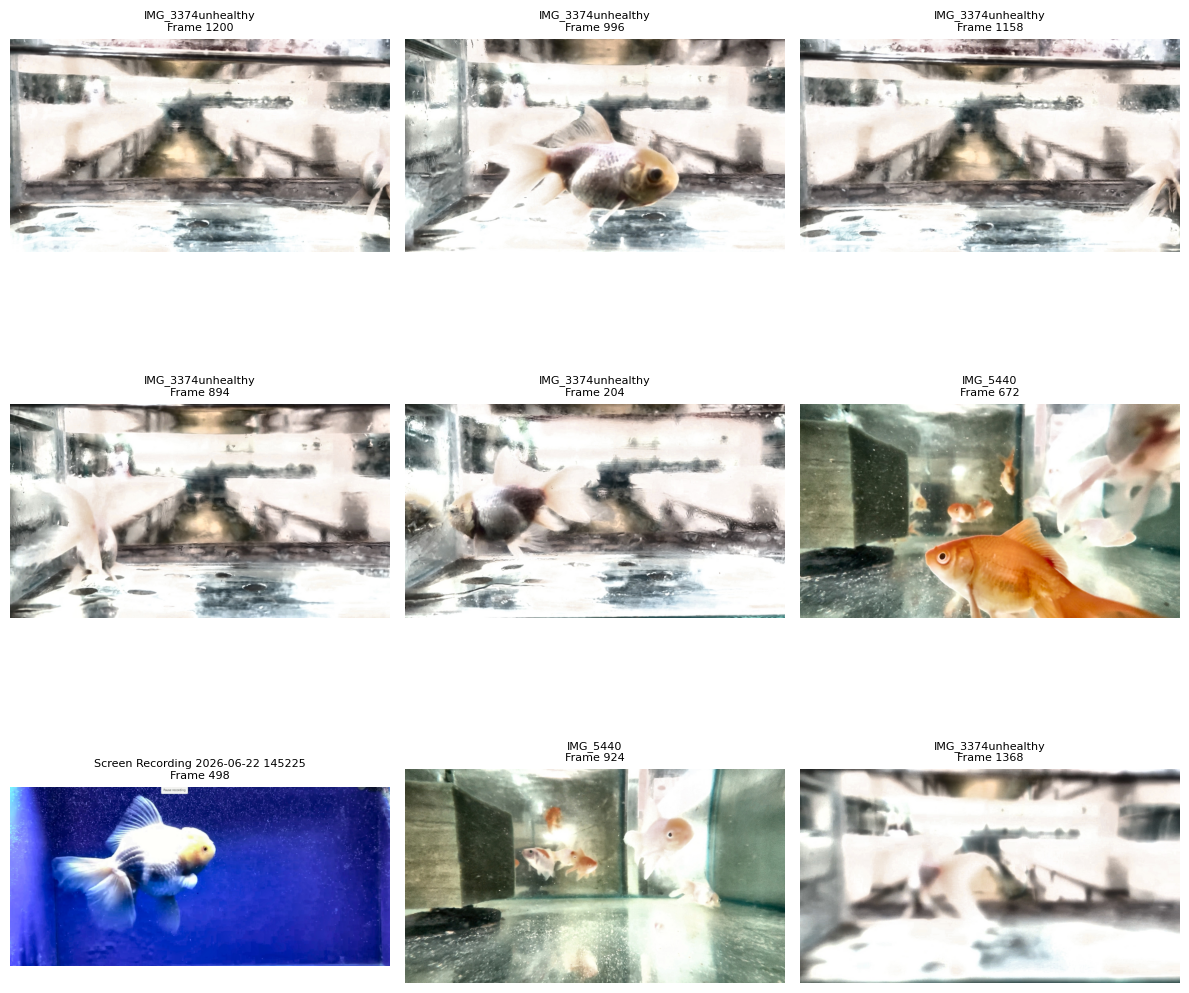

In [34]:
import random
import matplotlib.pyplot as plt
import cv2

sample = metadata.sample(9, random_state=42)

plt.figure(figsize=(12,12))

for i, (_, row) in enumerate(sample.iterrows(), 1):

    image = cv2.imread(row["original_path"])

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(3,3,i)

    plt.imshow(image)

    plt.title(
        f"{row['video']}\nFrame {row['frame_number']}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()

plt.show()